In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else: 
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data
file_path = "instruction-data.json"
url = (
 "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
 "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [101]:
import torch
from torch import nn

class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    def forward(self, x):
        return self.fc(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)
        return self.w_o(attn_output)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embedding(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x) 


def generate(model, idx, max_new_tokens, context_size, temperature=0.0, topk=None, eos_token_id=50256):
    is_training = model.training
    model.eval()
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_used)[:, -1, :]
        if topk is not None:
            topk_logits, _ = torch.topk(logits, topk)
            logits = torch.where(
                condition=logits < topk_logits[..., [-1]],
                input=torch.tensor(float('-inf')),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        
        idx = torch.cat([idx, next_token], dim=1)
        
        # 检查是否生成结束符，如果是则提前停止
        if next_token.item() == eos_token_id:
            break
    if is_training:
        model.train()
    return idx

def tokens_to_text(tokens, tokenizer):
    tokens = tokens.squeeze(0).tolist()  # 移除batch维度并转换为列表
    return tokenizer.decode(tokens)

def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0) # 添加batch维度


GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 1024,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": True,
}


def calculate_loss_single_batch(inputs, targets, model, device):
    criterion = nn.CrossEntropyLoss()
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    loss = criterion(outputs.flatten(0, 1), targets.view(-1))
    return loss


def calculate_loss(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calculate_loss_single_batch(inputs, labels, model, device)
        total_loss += loss.item()
    average_loss = total_loss / num_batches if num_batches > 0 else 0
    return average_loss

def train_loader_f(train_loader, val_loader, model, optimizer, device, num_epochs, val_freq):
    train_losses, val_losses, train_accs, val_accs, examples_seen = [], [], [], [], []
    global_steps = 0
    for epoch in range(num_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            loss = calculate_loss_single_batch(inputs, labels, model, device)
            loss.backward()
            optimizer.step()
            if global_steps % val_freq == 0:
                train_loss = calculate_loss(train_loader, model, device)
                val_loss = calculate_loss(val_loader, model, device)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                examples_seen.append((global_steps + 1) * inputs.shape[0])
                print(f"Epoch {epoch+1}/{num_epochs}, global steps: {global_steps+1}",
                    f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            global_steps += 1
    return train_losses, val_losses, examples_seen

import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f'Train {label}')
    ax1.plot(epochs_seen, val_values, label=f'Val {label}', linestyle='-.')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(label)
    ax1.legend(loc='best')
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel('Examples Seen')
    plt.title(f'Train and Val {label} vs Epochs and Examples Seen')
    plt.show()

In [2]:
data[234]

{'instruction': "What is the contraction for 'it is'?",
 'input': '',
 'output': "The contraction for 'it is' is 'it's.'"}

In [3]:
def format_input(entry):
    instruction = (
        f"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n"
        f"### Instruction:\n{entry['instruction']}"
    )
    inputs = f"### Input:\n\n{entry['input']}" if entry["input"] else ""
    return instruction + inputs

In [4]:
print(format_input(data[34])+"\n\n### Response:\n" + data[34]["output"])


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is the capital of Brazil?

### Response:
The capital of Brazil is Brasília.


In [5]:
train_num = int(len(data) * 0.85)
test_num = int(len(data) * 0.1)
val_num = len(data) - train_num - test_num
train_data = data[:train_num]
test_data = data[train_num : train_num + test_num]
val_data = data[train_num + test_num :]
print(f"Train data: {len(train_data)} entries")

Train data: 935 entries


In [38]:
train_data[1]

{'instruction': 'Edit the following sentence for grammar.',
 'input': 'He go to the park every day.',
 'output': 'He goes to the park every day.'}

In [74]:
import torch

class InstructionDataset:
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_data = []
        for entry in self.data:
            formatted_text = format_input(entry)
            full_text = formatted_text + "\n\n### Response:\n" + entry["output"]
            encoded_entry = tokenizer.encode(full_text)
            self.encoded_data.append(encoded_entry)
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.encoded_data[idx]

def custom_collate_fn(batch, pad_token_id=50256, ignore_id=-100, all_max_length=1024):
    inputs, targets = [], []
    max_length = max(len(item)+1 for item in batch)
    # print(batch[0])
    for item in batch:
        new_item = item.copy()
        # print(new_item)
        new_item = new_item + [pad_token_id] * (max_length - len(item))

        input = torch.tensor(new_item[:-1], dtype=torch.long)
        target = torch.tensor(new_item[1:], dtype=torch.long)
        mask = target == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            target[indices[1:]] = ignore_id

        if all_max_length is not None:
            input = input[:all_max_length]
            target = target[:all_max_length]
        
        inputs.append(input)
        targets.append(target)

    return torch.stack(inputs), torch.stack(targets)

In [75]:
a = [[1,2,3,4,5,6], [7,8,9], [10,100]]
inputs, targets = custom_collate_fn(a, pad_token_id=50256, ignore_id=-100, all_max_length=None)
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[    1,     2,     3,     4,     5,     6],
        [    7,     8,     9, 50256, 50256, 50256],
        [   10,   100, 50256, 50256, 50256, 50256]])
Targets:
 tensor([[    2,     3,     4,     5,     6, 50256],
        [    8,     9, 50256,  -100,  -100,  -100],
        [  100, 50256,  -100,  -100,  -100,  -100]])


In [76]:
b = torch.tensor([1,2,3,4,5,3])
mask = b == 3
indices = torch.nonzero(mask).squeeze()
print("Mask:\n", mask)
print("Indices:\n", indices)

Mask:
 tensor([False, False,  True, False, False,  True])
Indices:
 tensor([2, 5])


In [77]:
import tiktoken
from torch.utils.data import DataLoader

batch_size = 8

tokenizer = tiktoken.get_encoding('gpt2')
train_dataset = InstructionDataset(train_data ,tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False
)


In [78]:
i = 0
for ins, tars in train_loader:
    print(ins.shape, "  ", tars.shape)
    i += 1
    if i==5:
        break

torch.Size([8, 68])    torch.Size([8, 68])
torch.Size([8, 73])    torch.Size([8, 73])
torch.Size([8, 64])    torch.Size([8, 64])
torch.Size([8, 65])    torch.Size([8, 65])
torch.Size([8, 87])    torch.Size([8, 87])


In [88]:
print(len(train_loader))

116


## 微调模型

In [90]:
gpt = GPTModel(GPT_CONFIG_124M)
gpt.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"))


C:\Users\86178\AppData\Local\Temp\ipykernel_1976\171836950.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpt.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-from-

<All keys matched successfully>

In [91]:
gpt.eval()

GPTModel(
  (embedding): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (w_o): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (fc): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q)

In [92]:
# t1 = """
# Below is an instruction that describes a task. Write a response that 
# appropriately completes the request.


# ### Instruction:
# Convert the active sentence to passive: 'The chef cooks the meal every day.'
# """

# idx1 = generate(gpt, text_to_tokens(t1, tokenizer), max_new_tokens=256, context_size=GPT_CONFIG_124M["context_size"])
# print(tokens_to_text(idx1))

In [93]:
# print(tokens_to_text(idx1, tokenizer))

In [94]:
gpt.to('cuda')

GPTModel(
  (embedding): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=True)
        (w_k): Linear(in_features=768, out_features=768, bias=True)
        (w_v): Linear(in_features=768, out_features=768, bias=True)
        (w_o): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (fc): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (w_q)

In [95]:
t_loss = calculate_loss( train_loader, gpt, 'cuda', 10)
v_loss = calculate_loss(val_loader, gpt, 'cuda', 10)
print(f'train_loss: {t_loss}')
print(f"val_loss {v_loss}")

train_loss: 4.156838440895081
val_loss 4.1180457047053745


In [96]:
optimizer = torch.optim.AdamW(gpt.parameters(), lr=0.0001, weight_decay=0.05)

device = 'cuda'
train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, gpt, optimizer, device, num_epochs=2, val_freq=20)

Epoch 1/2, global steps: 1 Train Loss: 3.2070, Val Loss: 3.2092
Epoch 1/2, global steps: 21 Train Loss: 1.0806, Val Loss: 1.1070
Epoch 1/2, global steps: 41 Train Loss: 0.9143, Val Loss: 0.9875
Epoch 1/2, global steps: 61 Train Loss: 0.8306, Val Loss: 0.9246
Epoch 1/2, global steps: 81 Train Loss: 0.7632, Val Loss: 0.8771
Epoch 1/2, global steps: 101 Train Loss: 0.7107, Val Loss: 0.8579
Epoch 2/2, global steps: 121 Train Loss: 0.6557, Val Loss: 0.8413
Epoch 2/2, global steps: 141 Train Loss: 0.6228, Val Loss: 0.8365
Epoch 2/2, global steps: 161 Train Loss: 0.5973, Val Loss: 0.8350
Epoch 2/2, global steps: 181 Train Loss: 0.5655, Val Loss: 0.7999
Epoch 2/2, global steps: 201 Train Loss: 0.5345, Val Loss: 0.8123
Epoch 2/2, global steps: 221 Train Loss: 0.5101, Val Loss: 0.7929


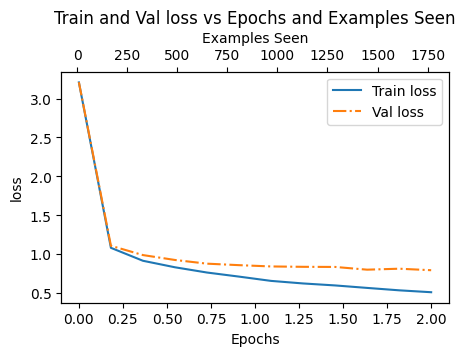

In [97]:
epochs_seen = torch.linspace(0, 2, len(train_losses))
plot_values(epochs_seen, examples_seen, train_losses, val_losses, label='loss')

In [107]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    inputs = format_input(entry)
    idx = generate(gpt, text_to_tokens(inputs, tokenizer).to('cuda'), max_new_tokens=256, context_size=GPT_CONFIG_124M["context_size"], temperature=1, topk=50)
    outputs = tokens_to_text(idx, tokenizer)
    response = outputs[len(inputs):].replace("\n\n### Response:\n", "").replace("<|endoftext|>", "").strip()
    test_data[i]["model_response"] = response
    # print(inputs)
    # print(f"model :{response}")
    # print(f"real :{entry['output']}")
    # if i ==2:
    #     break

with open("test_data_with_responses.json", "w", encoding="utf-8") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 110/110 [00:49<00:00,  2.23it/s]


In [ ]:
from openai import OpenAI

client = OpenAI(
    api_key="xxx",  
    base_url="https://api.moonshot.cn/v1",
)

def generate_model_score(json_data, client):
    scores = []
    
    for entry in json_data:
        try:
            completion = client.chat.completions.create(
                model="kimi-k2.5",  
                messages=[
                    {
                        "role": "system",  
                        "content": "You are a helpful assistant for scoring model responses. Only return an integer score from 1 to 100."
                    },
                    {
                        "role": "user",
                        "content": (
                            f"Input: {format_input(entry)}\n"
                            f"Correct response: {entry['output']}\n"
                            f"Model response: {entry['model_response']}\n\n"
                            f"Score (1-100):"
                        )
                    }
                ],
                temperature=0.1,
                max_tokens=10,
            )
            score = completion.choices[0].message.content.strip()
            score_int = int(''.join(filter(str.isdigit, score)) or 0)
            scores.append(score_int)
            
        except Exception as e:
            print(f"Error: {e}")
            scores.append(None)
    
    return scores

In [ ]:
with open("test_data_with_responses.json", "r", encoding="utf-8") as file:
    test_data_with_responses = json.load(file)

t_data_ = test_data_with_responses[:50]  
scores = generate_model_score(t_data_, client)
print(sum(scores) / len(scores))